#Импорты

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

In [ ]:
print(test)
print(train)

            id          brand                   model  model_year  milage  \
0       188533           Land          Rover LR2 Base        2015   98000   
1       188534           Land       Rover Defender SE        2020    9142   
2       188535           Ford      Expedition Limited        2022   28121   
3       188536           Audi           A6 2.0T Sport        2016   61258   
4       188537           Audi    A6 2.0T Premium Plus        2018   59000   
...        ...            ...                     ...         ...     ...   
125685  314218  Mercedes-Benz  GL-Class GL 450 4MATIC        2014   83315   
125686  314219           Audi          Q7 55 Prestige        2019   29336   
125687  314220           Audi    A6 3.0T Premium Plus        2012   77634   
125688  314221           Audi         Q7 3.0T Premium        2012  112000   
125689  314222      Chevrolet                Tahoe LT        2018   66840   

       fuel_type                                             engine  \
0   

#Анализ и обработка

In [ ]:
print(train.columns)

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')


In [ ]:
y_train = train['price']
X_train = train.drop(columns=['price','id'])
X_test = test.drop(columns='id')

In [ ]:
numeric_features = X_test.select_dtypes(include=['int64', 'float64']).columns.tolist()[:-1]
categorical_features = X_test.select_dtypes(include=['object', 'category']).columns.tolist()

#Посмотрим, сколько нанов, сколько дубликатов

In [ ]:
print(train.duplicated().sum())
print(test.duplicated().sum())
print(train.isna().sum())
print(test.isna().sum())
print(train.isnull().sum())
print(test.isnull().sum())


0
0
id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64
id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        3383
engine              0
transmission        0
ext_col             0
int_col             0
accident         1632
clean_title     14239
dtype: int64
id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64
id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type  

📈 Корреляция признаков с price:
price           1.000000
model_year      0.231795
engine          0.208285
accident        0.123034
int_col         0.035174
fuel_type       0.034321
brand           0.017657
transmission    0.014560
id             -0.000877
ext_col        -0.017342
model          -0.029865
clean_title    -0.089433
milage         -0.283067
Name: price, dtype: float64


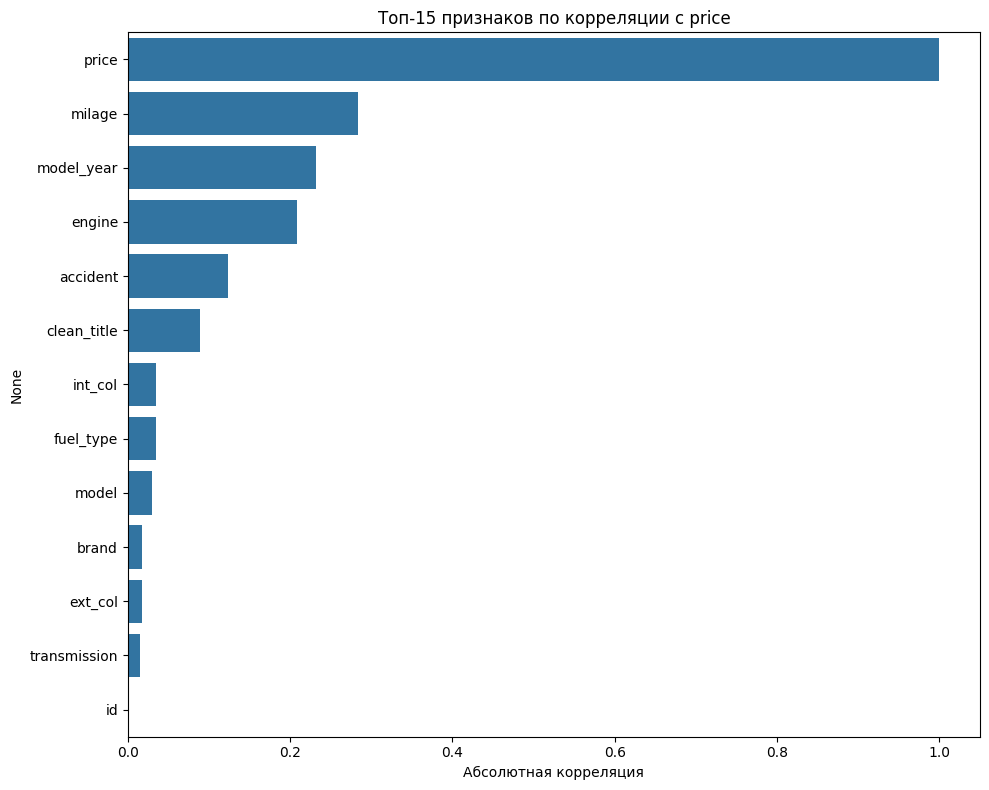

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_corr = train.copy()
for col in df_corr.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_corr[col] = df_corr[col].fillna('Unknown')
    df_corr[col] = le.fit_transform(df_corr[col])

correlations = df_corr.corr()['price'].sort_values(ascending=False)

print("📈 Корреляция признаков с price:")
print(correlations)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
top_corr = correlations.abs().sort_values(ascending=False).head(15)
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Топ-15 признаков по корреляции с price')
plt.xlabel('Абсолютная корреляция')
plt.tight_layout()
plt.show()

#Заполним наны по логике, дубликатов нет. Если об инцидентах не сообщалось, то логично указать None reported

In [ ]:


X_train['clean_title'].fillna('NO',inplace=True)
X_test['clean_title'].fillna('NO',inplace=True)
X_train['accident'].fillna('None reported',inplace=True)
X_test['accident'].fillna('None reported',inplace=True)
mode_val = X_train['fuel_type'].mode()[0]
X_train['fuel_type'].fillna(mode_val, inplace=True)
X_test['fuel_type'].fillna(mode_val, inplace=True)

print(X_train.isna().sum())
print(X_test.isna().sum())


brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
dtype: int64
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
dtype: int64


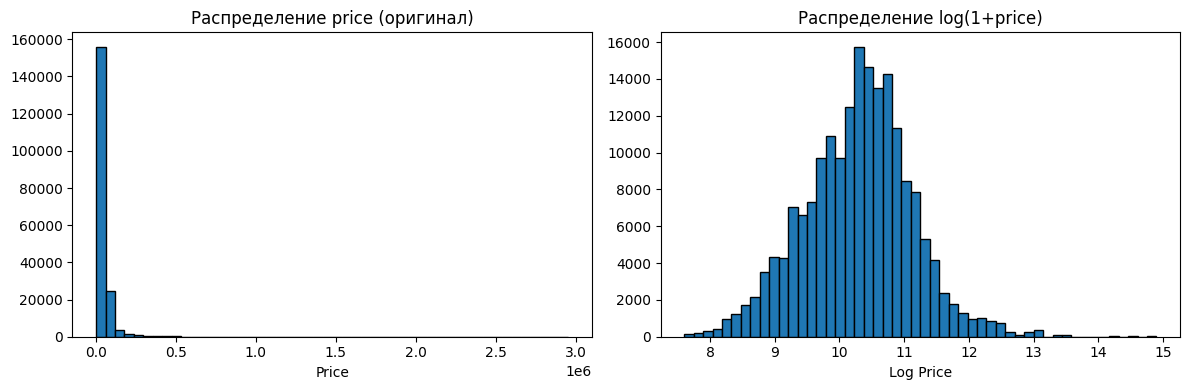

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train['price'], bins=50, edgecolor='black')
plt.title('Распределение price (оригинал)')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(train['price']), bins=50, edgecolor='black')
plt.title('Распределение log(1+price)')
plt.xlabel('Log Price')

plt.tight_layout()
plt.show()

#Очень неравномерное распределение целевой переменной, можно попробовать логарифмировать цены

In [ ]:
# Сколько машин с ценой < $1000?
cheap_cars = (train['price'] < 1000).sum()
print(f"🚗 Машин дешевле $1,000: {cheap_cars} ({cheap_cars/len(train)*100:.1f}%)")

# Сколько с ценой = 0?
zero_cars = (train['price'] == 0).sum()
print(f"🚗 Машин с ценой $0: {zero_cars}")

# Статистика
print("\n📊 Статистика price:")
print(train['price'].describe())

# Первые 20 значений
print("\n💰 Первые 20 цен:")
print(train['price'].head(20).values)

🚗 Машин дешевле $1,000: 0 (0.0%)
🚗 Машин с ценой $0: 0

📊 Статистика price:
count    1.885330e+05
mean     4.387802e+04
std      7.881952e+04
min      2.000000e+03
25%      1.700000e+04
50%      3.082500e+04
75%      4.990000e+04
max      2.954083e+06
Name: price, dtype: float64

💰 Первые 20 цен:
[ 4200  4999 13900 45000 97500 29950 28500 12500 62890  4000  7950 19000
 51500 12300 56900 44900 68500 55000  9999 46900]


In [ ]:
# Процентили цены
print("📊 Процентили price:")
for p in [90, 95, 99, 99.5, 99.9]:
    val = train['price'].quantile(p/100)
    count = (train['price'] > val).sum()
    print(f"{p}th percentile: ${val:,.0f} → {count} машин дороже")

📊 Процентили price:
90th percentile: $78,500 → 18802 машин дороже
95th percentile: $107,900 → 9386 машин дороже
99th percentile: $259,500 → 1840 машин дороже
99.5th percentile: $399,900 → 899 машин дороже
99.9th percentile: $749,950 → 148 машин дороже


#Есть выбросы в виде очень дорогих машин, нужно исключить их, чтобы предсказания были точнее, однако модель будет плохо предсказывать дорогие машины

In [ ]:
X_train[categorical_features].nunique()

,0
brand,57
model,1897
fuel_type,7
engine,1117
transmission,52
ext_col,319
int_col,156
accident,2
clean_title,2


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for x in categorical_features:
  X_train[x] = encoder.fit_transform(X_train[x])
  X_test[x] = encoder.fit_transform(X_test[x])
print(X_train)

        brand  model  model_year  milage  fuel_type  engine  transmission  \
0          31    495        2007  213000          2     116            38   
1          28    930        2002  143250          2     366            38   
2           9   1575        2002  136731          1     640            38   
3          16    758        2017   19500          2     863            49   
4          36   1077        2021    7388          2     259            23   
...       ...    ...         ...     ...        ...     ...           ...   
188528      8    604        2017   49000          2     866            49   
188529     36    206        2018   28600          2     770            31   
188530     36    223        2021   13650          2     921            23   
188531      3   1471        2022   13895          2     512             1   
188532     43   1028        2016   59500          2     364            49   

        ext_col  int_col  accident  clean_title  
0           312       71 

In [ ]:
!pip install catboost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np


threshold = train['price'].quantile(0.99)
mask = train['price'] <= threshold

X_train_clean = X_train[mask].copy()
y_train_clean = y_train[mask].copy()

y_train_log = np.log1p(y_train_clean)


model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=50,
    loss='squared_error'
)

model.fit(X_train_clean, y_train_log)
print("\n✅ Модель обучена!")


y_train_pred_log = model.predict(X_train_clean)
y_test_pred_log = model.predict(X_test)

y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)
y_train_orig = np.expm1(y_train_log)


print("\n" + "=" * 60)
print("📈 МЕТРИКИ НА TRAIN (в реальных ценах)")
print("=" * 60)

train_mse = mean_squared_error(y_train_orig, y_train_pred)
train_mae = mean_absolute_error(y_train_orig, y_train_pred)
train_r2 = r2_score(y_train_orig, y_train_pred)

print(f"MSE:  {train_mse:,.2f}")
print(f"MAE:  {train_mae:,.2f}")
print(f"RMSE: {np.sqrt(train_mse):,.2f}")
print(f"R²:   {train_r2:.4f} ({train_r2*100:.1f}% дисперсии объяснено)")


scale_factor = y_train.mean() / y_test_pred.mean()
y_test_pred = y_test_pred * scale_factor

submission = pd.DataFrame({
    'id': test['id'],
    'price': y_test_pred.round(2)
})
submission.to_csv('submission_gradient_boosting.csv', index=False)

print(f"\n🔧 Коэффициент калибровки: {scale_factor:.4f}")
print(f"✅ Средняя в submission: ${y_test_pred.mean():,.2f}")
print("✅ Сохранено в submission_gradient_boosting.csv")

      Iter       Train Loss   Remaining Time 
         1           0.5654            4.59m
         2           0.5009            4.64m
         3           0.4481            4.55m
         4           0.4053            4.57m
         5           0.3701            4.54m
         6           0.3417            4.56m
         7           0.3182            4.55m
         8           0.2992            4.54m
         9           0.2835            4.69m
        10           0.2705            5.20m
        11           0.2599            5.90m
        12           0.2511            6.61m
        13           0.2439            7.36m
        14           0.2379            7.57m
        15           0.2329            7.87m
        16           0.2287            7.95m
        17           0.2252            8.03m
        18           0.2223            8.13m
        19           0.2196            8.21m
        20           0.2175            8.38m
        21           0.2158            8.30m
        2

✅ Модель обучена!

============================================================
📈 МЕТРИКИ НА TRAIN (в реальных ценах)
============================================================
MSE:  541,424,288.10
MAE:  11,988.15
RMSE: 23,268.53
R²:   0.5282 (52.8% дисперсии объяснено)

🔧 Коэффициент калибровки: 1.2311
✅ Средняя в submission: $43,878.02
✅ Сохранено в submission_gradient_boosting.csv

#Не самые лучшие результаты, но для такой сложной задачи достаточно неплохо